# 🛒 Online Retail Exploratory Data Analysis & ETL
**Author:** Fauziya Yusuf  
**Objective:** Clean, validate, and prepare transactional retail data for SQL extraction and Power BI modeling.

---

## 1. Environment Setup & Data Loading

In [10]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [17]:
# Load the file using its exact name (with the underscore) and the encoding fix
df = pd.read_csv('Online_Retail.csv', encoding='ISO-8859-1')

# Display the first 5 rows to confirm it works!
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Data Inspection
Checking data types, entry counts, and identifying missing values across key columns like `CustomerID` and `Description`.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [21]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [22]:
# Filter out negative quantities and negative unit prices
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] >= 0)]

# Run describe again to verify the minimums are fixed!
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,531283.000000,531283.000000,397924.000000
mean,10.655299,3.898954,15294.315171
std,156.830617,35.876279,1713.169877
min,1.000000,0.000000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


In [24]:
# 1. Create a hard, independent copy of the filtered data (this stops the warnings!)
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] >= 0)].copy()

# 2. Safely add our new columns to our independent dataframe
df_clean['Total_Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 3. Check our work cleanly
df_clean[['InvoiceDate', 'Total_Sales', 'Year', 'Month', 'DayOfWeek', 'Hour']].head()

C:\Users\user\AppData\Local\Temp\ipykernel_28068\492358737.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


,InvoiceDate,Total_Sales,Year,Month,DayOfWeek,Hour
0,2010-12-01 08:26:00,15.30,2010,12,Wednesday,8
1,2010-12-01 08:26:00,20.34,2010,12,Wednesday,8
2,2010-12-01 08:26:00,22.00,2010,12,Wednesday,8
3,2010-12-01 08:26:00,20.34,2010,12,Wednesday,8
4,2010-12-01 08:26:00,20.34,2010,12,Wednesday,8


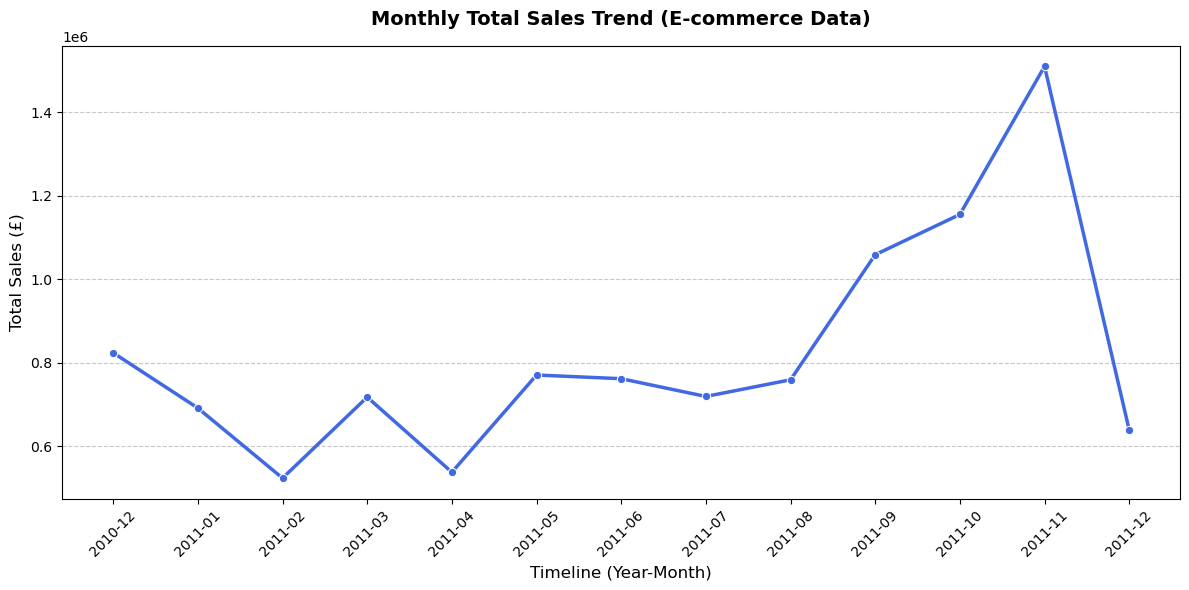

<Figure size 640x480 with 0 Axes>

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by Year and Month to calculate total revenue
monthly_sales = df_clean.groupby(['Year', 'Month'])['Total_Sales'].sum().reset_index()

# Create a clean 'Year-Month' string column for the X-axis mapping
monthly_sales['Year_Month'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)
monthly_sales = monthly_sales.sort_values('Year_Month')

# 2. Set up the plotting canvas
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Year_Month', y='Total_Sales', marker='o', color='royalblue', linewidth=2.5)

# 3. Title restored with E-commerce focus
plt.title('Monthly Total Sales Trend (E-commerce Data)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and show the chart
plt.tight_layout()
plt.show()

plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')

### 📈 Executive Insights: Monthly Sales Trends

* **Seasonal Revenue Growth:** The business experiences a massive, undeniable surge in total revenue during the late third and fourth quarters (Q3/Q4), peaking dramatically in **November**.
* **Operational Action:** This clear peak indicates a heavy reliance on a holiday shopping rush. Stakeholders should use this timeline to proactively scale up server capacity, optimize website traffic limits, and secure inventory levels by September or October to prevent sudden stockouts.

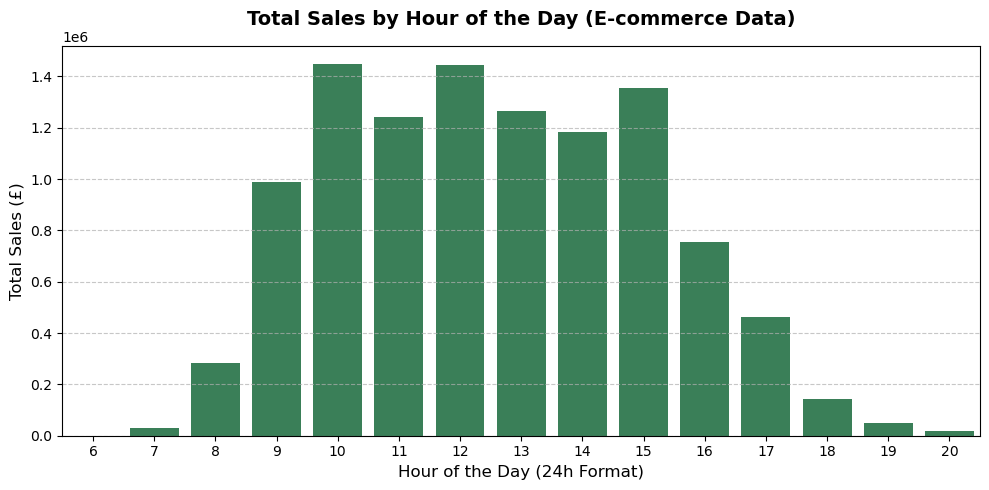

<Figure size 640x480 with 0 Axes>

In [39]:
# Group by Hour and calculate total sales
hourly_sales = df_clean.groupby('Hour')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_sales, x='Hour', y='Total_Sales', color='seagreen')
plt.title('Total Sales by Hour of the Day (E-commerce Data)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24h Format)', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.savefig('Hourly_sales_trend.png', dpi=300, bbox_inches='tight')

### 🕒 Executive Insights: Peak Purchasing Windows

* **High-Volume Traffic Windows:** Customer purchasing behavior heavily concentrates in midday intervals, spiking distinctly at **10:00 AM** and **12:00 PM (Noon)**, followed by a final afternoon rush at **3:00 PM (15:00)**.
* **Targeted Marketing Potential:** Transaction frequency is virtually non-existent before 7:00 AM and after 8:00 PM (20:00). 
* **Business Action:** Marketing and sales teams should schedule time-sensitive marketing push notifications or flash discount campaigns precisely at **9:45 AM** and **11:45 AM** to capture active users right as these peak demand waves begin.

C:\Users\user\AppData\Local\Temp\ipykernel_28068\539661104.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Total_Sales', y='Description', palette='Blues_r')


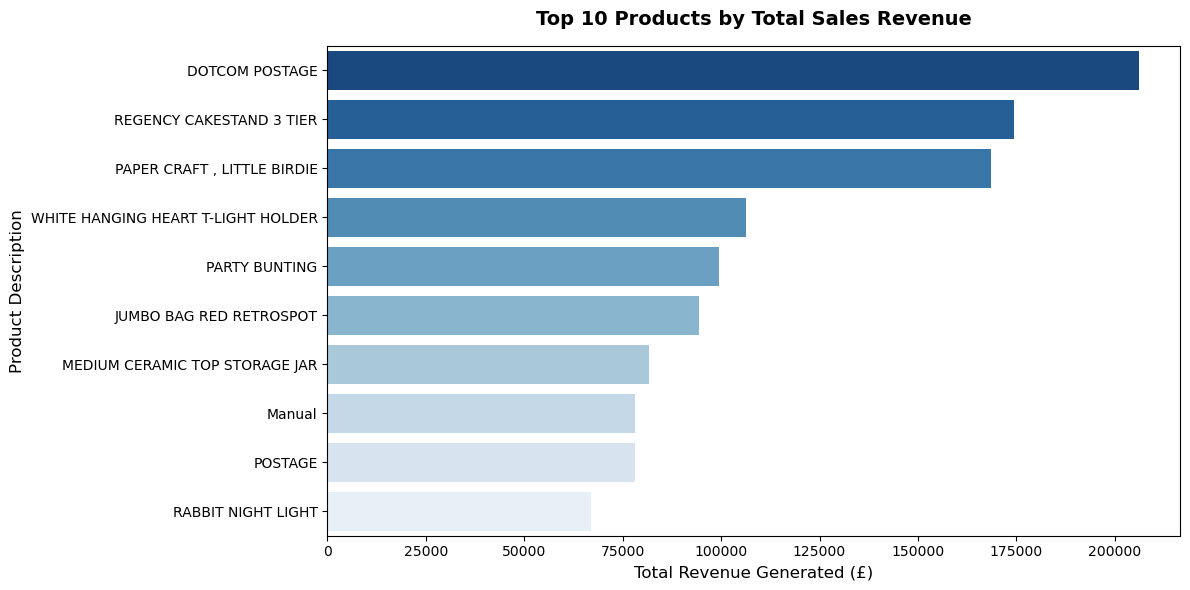

<Figure size 640x480 with 0 Axes>

In [40]:
# Group by product description and find the top 10
top_products = df_clean.groupby('Description')['Total_Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='Total_Sales', y='Description', palette='Blues_r')
plt.title('Top 10 Products by Total Sales Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Generated (£)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('top_products.png', dpi=300, bbox_inches='tight')

### 📦 Executive Insights: Core Revenue Generators

* **Primary Retail Drivers:** When looking at physical retail products, items like the **REGENCY CAKESTAND 3 TIER** and the **WHITE HANGING HEART T-LIGHT HOLDER** stand out as major operational revenue engines for the storefront.
* **Data Transparency Note:** Non-product line items such as **DOTCOM POSTAGE**, **POSTAGE**, and **Manual** appear prominently in the revenue ranking. This reveals that auxiliary service fees significantly impact gross transaction totals.
* **Strategic Next Steps:** For a strict inventory breakdown, future iterations of this analysis should segment core product inventory from logistical service fulfillment fees to isolate true consumer product demand.

C:\Users\user\AppData\Local\Temp\ipykernel_28068\2089448143.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Total_Sales', y='Country', palette='Purples_r')


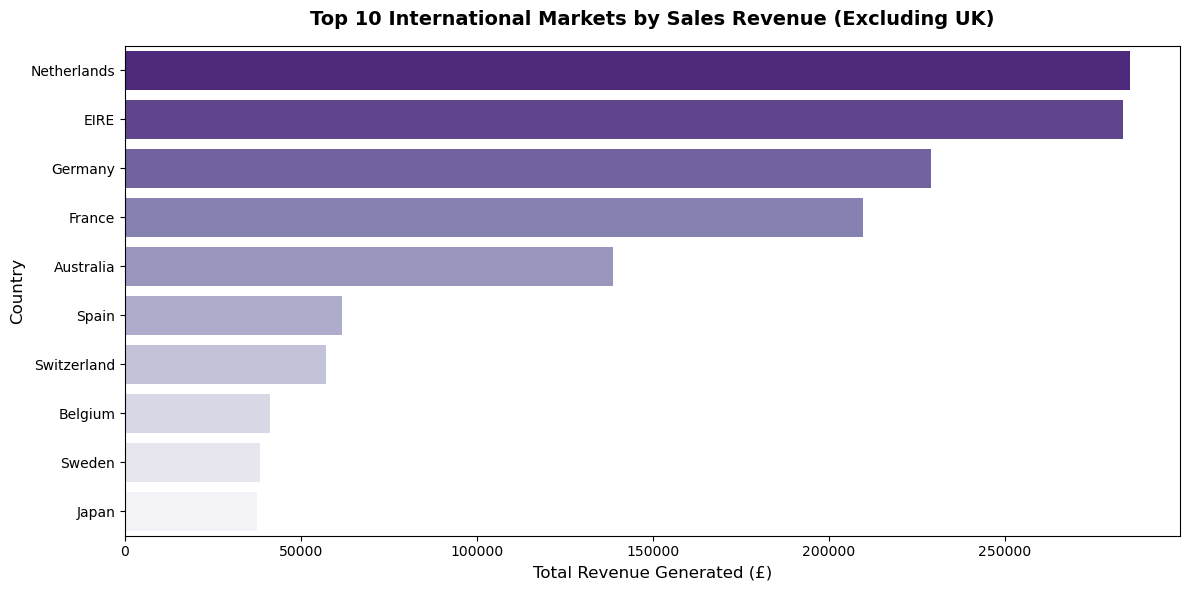

<Figure size 640x480 with 0 Axes>

In [41]:
# Filter out United Kingdom to see top international markets
international_sales = df_clean[df_clean['Country'] != 'United Kingdom']
top_countries = international_sales.groupby('Country')['Total_Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='Total_Sales', y='Country', palette='Purples_r')
plt.title('Top 10 International Markets by Sales Revenue (Excluding UK)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Generated (£)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('top_countries.png', dpi=300, bbox_inches='tight')

### 🌍 Executive Insights: International Revenue Drivers

* **Strategic Data Selection:** The United Kingdom was intentionally excluded from this analysis. Because this is a UK-based retailer, UK transactions represent over 80% of total volume. Removing it prevents the chart scale from being distorted and allows clear visibility into secondary markets.
* **Key Global Markets:** The **Netherlands** and **EIRE (Ireland)** stand out as the dominant international drivers, significantly outperforming Germany and France in total sales revenue.
* **Business Action:** Marketing and logistics teams should prioritize asset allocation and targeted campaigns in the Netherlands and EIRE to maximize return on international expansion.